# Differential Expression Analysis of Yoruba HapMap RNA-seq with pylimma

This tutorial walks through a standard `limma`-style RNA-seq
differential-expression workflow using pylimma. It mirrors the
equivalent analysis path from the R limma User's Guide.


**R-parity validation**: the sibling notebook [`yoruba_R_vs_Python.ipynb`](yoruba_R_vs_Python.ipynb) runs R limma 3.66.0 on the same input and compares the outputs numerically.

## Dataset

**Pickrell et al. 2010, *Nature* 464:768-772**: RNA-seq of lymphoblastoid cell lines from 69 Yoruba HapMap individuals. Contrast: female vs male, dominated by X- and Y-chromosome genes.

## Pipeline

1. Load counts and sample metadata
2. Library-size sanity check
3. Filter low-expression genes
4. log-CPM kernel-density plot (before / after filter)
5. Multi-dimensional scaling (coloured by group)
6. Build the design matrix
7. Run `voom`
8. Fit linear models and contrasts
9. Empirical Bayes moderation
10. Extract the top table
11. MD plot
12. Volcano plot
13. Heatmap of top 50 DE genes (row-ordered by signed t-statistic)
14. Summary


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(REPO))
sys.path.insert(0, str(REPO / 'data'))

import generate_data as gd

import pylimma

pd.set_option('display.width', 120)
pd.set_option('display.max_columns', 10)
np.set_printoptions(precision=4, suppress=True)

# Shared plotting helpers used by every tutorial.

def _log_cpm(mat, lib_size):
    cpm = mat.div(lib_size, axis=1) * 1e6 if hasattr(mat, 'div') \
          else (mat / lib_size) * 1e6
    return np.log2(cpm + 1e-2)


def plot_log_cpm_density(mat, ax, title=""):
    '''Kernel-smoothed log-CPM density, one line per sample.

    Matches edgeR/limma's standard density plot (limma User's Guide
    Figure 15.1): a Gaussian KDE per sample drawn on a shared grid.
    '''
    from scipy.stats import gaussian_kde
    arr = mat.values if hasattr(mat, 'values') else np.asarray(mat)
    # Shared evaluation grid spanning the combined range.
    lo, hi = np.nanmin(arr), np.nanmax(arr)
    grid = np.linspace(lo, hi, 200)
    for j in range(arr.shape[1]):
        col = arr[:, j]
        col = col[np.isfinite(col)]
        if col.size < 2:
            continue
        kde = gaussian_kde(col)
        ax.plot(grid, kde(grid), linewidth=0.8, alpha=0.7)
    ax.set_xlabel('log2 CPM')
    ax.set_ylabel('Density')
    ax.set_title(title)


def mds_coords(mat, top=500):
    '''Pairwise leading-logFC MDS, matching R limma's plotMDS.default.

    Returns the (n_samples, ndim) coordinate matrix and the percent of
    variance explained per dimension. We reuse pylimma's private
    _mds_coordinates for consistency with plot_mds().
    '''
    from pylimma.plotting import _mds_coordinates
    r = _mds_coordinates(np.asarray(mat, dtype=np.float64), top=top,
                         gene_selection='pairwise', ndim=2)
    lam = np.maximum(r['eigen_values'], 0.0)
    coords = r['eigen_vectors'] * np.sqrt(lam)
    return coords, r['var_explained']


def plot_mds_coloured(mat, groups, ax, top=500, title='MDS'):
    '''MDS scatter plot coloured by sample group.'''
    coords, var_exp = mds_coords(mat, top=top)
    pct = np.round(var_exp * 100).astype(int)
    groups = np.asarray(groups)
    levels = sorted(pd.unique(groups))
    palette = plt.get_cmap('tab10').colors
    for k, level in enumerate(levels):
        m = groups == level
        ax.scatter(coords[m, 0], coords[m, 1],
                   s=55, color=palette[k % len(palette)],
                   label=str(level), edgecolor='k', linewidth=0.3)
    ax.axhline(0, color='grey', linewidth=0.4, linestyle=':')
    ax.axvline(0, color='grey', linewidth=0.4, linestyle=':')
    ax.set_xlabel(f'Leading logFC dim 1 ({pct[0]}%)')
    ax.set_ylabel(f'Leading logFC dim 2 ({pct[1]}%)')
    ax.set_title(title)
    ax.legend(fontsize=8, frameon=False)


def plot_heatmap(E, groups, fit, n_top=50, ax=None):
    '''Heatmap of top-n DE rows showing BOTH directions.

    Picks the top n/2 genes with the most positive t and the top n/2
    with the most negative t (by smallest p within each side), then
    stacks them - up-regulated in the contrast at top, down-regulated
    at bottom. Row z-scored.'''
    t = np.asarray(fit['t']).ravel()
    p = np.asarray(fit['p_value']).ravel()
    half = n_top // 2
    up_pool   = np.where(t > 0)[0]
    down_pool = np.where(t < 0)[0]
    top_up    = up_pool[np.argsort(p[up_pool])[:half]]
    top_down  = down_pool[np.argsort(p[down_pool])[:n_top - half]]
    # Sort each block by signed t descending so most-up is top and
    # most-down is bottom.
    top_up   = top_up[np.argsort(-t[top_up])]
    top_down = top_down[np.argsort(-t[top_down])]
    ordered  = np.concatenate([top_up, top_down])

    mat = E[ordered]
    col_order = np.argsort(groups)
    mat_sorted = mat[:, col_order]
    z = (mat_sorted - mat_sorted.mean(axis=1, keepdims=True)) / \
        (mat_sorted.std(axis=1, keepdims=True) + 1e-8)

    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 8))
    im = ax.imshow(z, aspect='auto', cmap='RdBu_r', vmin=-2, vmax=2)
    ax.set_xticks(range(len(col_order)))
    ax.set_xticklabels(np.asarray(groups)[col_order], rotation=90, fontsize=6)
    ax.set_yticks([])
    ax.set_title(f'Top {n_top} DE genes (top {half} up + top {n_top - half} down; row z-scored)')
    return ax, im, ordered


## 1. Load counts and sample metadata

In [2]:
data = gd.load_yoruba()
counts  = data['counts']
targets = data['targets']

print(f"counts shape: {counts.shape}  (genes x samples)")
group = targets["gender"].astype(str)
print("\ngender breakdown:")
print(group.value_counts())
targets.head()

counts shape: (38415, 69)  (genes x samples)

gender breakdown:
gender
female    40
male      29
Name: count, dtype: int64


,num.tech.reps,population,study,gender
NA18486,2,YRI,Pickrell,male
NA18498,2,YRI,Pickrell,male
NA18499,2,YRI,Pickrell,female
NA18501,2,YRI,Pickrell,male
NA18502,2,YRI,Pickrell,female


## 2. Library sizes

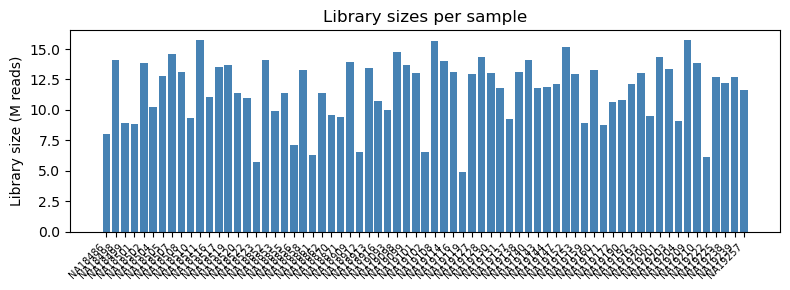

min: 4.9M,  max: 15.7M


In [3]:
lib_size = counts.sum(axis=0)

fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(range(len(lib_size)), lib_size.values / 1e6, color='steelblue')
ax.set_xticks(range(len(lib_size)))
ax.set_xticklabels(counts.columns, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Library size (M reads)')
ax.set_title('Library sizes per sample')
fig.tight_layout()
plt.show()

print(f"min: {lib_size.min() / 1e6:.1f}M,  max: {lib_size.max() / 1e6:.1f}M")

## 3. Filter low-expression genes

Keep genes with CPM > (10 / median library size in millions) in at
least as many samples as the smallest group. This rule of thumb,
from the limma User's Guide, removes ~half the low-count noise
without sacrificing real DE signal.

In [4]:
cpm = counts.div(lib_size, axis=1) * 1e6
n_per_group = group.value_counts().min()
cutoff = 10.0 / (lib_size.median() / 1e6)
keep = (cpm > cutoff).sum(axis=1) >= n_per_group
counts_f = counts.loc[keep]
print(f"filter kept {keep.sum():,} / {len(keep):,} genes "
      f"({100 * keep.mean():.1f}%)")

filter kept 17,860 / 38,415 genes (46.5%)


## 4. log-CPM density before / after filter

Kernel density estimate per sample on a shared grid. Before
filtering there is a big mass near zero-expression; filtering
removes it and the sample densities overlap cleanly.

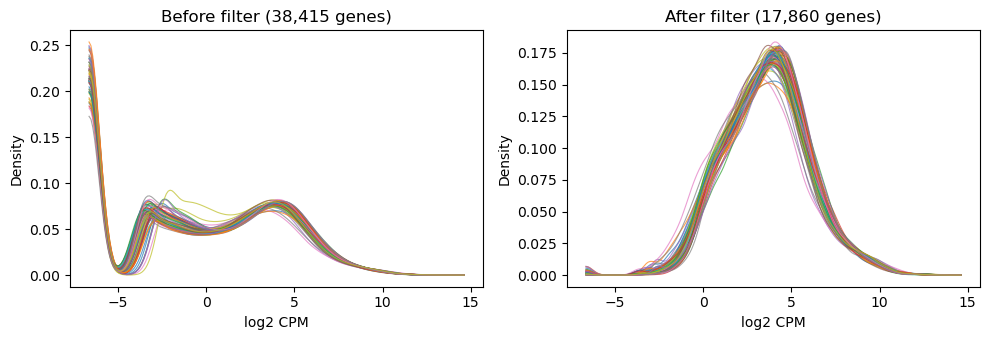

In [5]:
lcpm_before = _log_cpm(counts,   lib_size)
lcpm_after  = _log_cpm(counts_f, lib_size)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5), sharex=True)
plot_log_cpm_density(lcpm_before, ax1,
                     f"Before filter ({len(counts):,} genes)")
plot_log_cpm_density(lcpm_after,  ax2,
                     f"After filter ({len(counts_f):,} genes)")
fig.tight_layout()
plt.show()

## 5. MDS (coloured by group)

Samples projected into 2D via the top-500 leading log-FCs. Tight
clusters separated along the biological axis of interest indicate
a well-structured experiment.

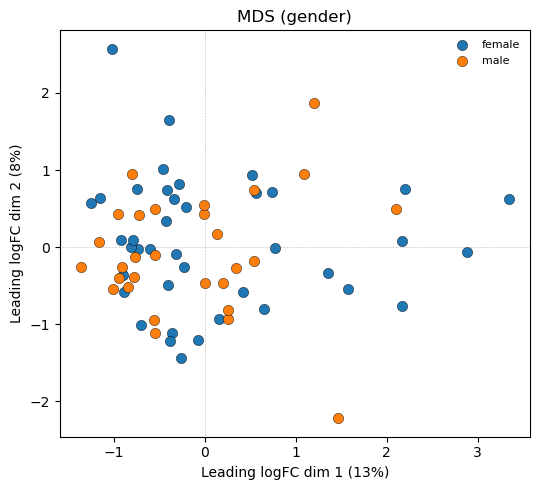

In [6]:
fig, ax = plt.subplots(figsize=(5.5, 5))
plot_mds_coloured(lcpm_after.values, group.values, ax,
                  top=500, title='MDS (gender)')
fig.tight_layout()
plt.show()

## 6. Design matrix

Two-group cell-means design; contrast = `female - male`.

In [7]:
design, C = gd.build_two_group_design(group)
design_df = pd.DataFrame(
    design, index=counts_f.columns,
    columns=sorted(group.unique()),
)
print('Design matrix:')
print(design_df)
print(f"\nContrast (female - male): {C.ravel()}")

Design matrix:
         female  male
NA18486     0.0   1.0
NA18498     0.0   1.0
NA18499     1.0   0.0
NA18501     0.0   1.0
NA18502     1.0   0.0
...         ...   ...
NA19222     1.0   0.0
NA19225     1.0   0.0
NA19238     1.0   0.0
NA19239     0.0   1.0
NA19257     1.0   0.0

[69 rows x 2 columns]

Contrast (female - male): [-1.  1.]


## 7. voom

`voom` models the mean-variance trend in log-CPM space and returns
per-observation precision weights. The plot below is the trend
fit; the scatter behind it is per-gene variance vs mean
expression.

/Users/John/miniconda3/lib/python3.11/site-packages/h5py/__init__.py:36: UserWarning: h5py is running against HDF5 1.14.3 when it was built against 1.14.2, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


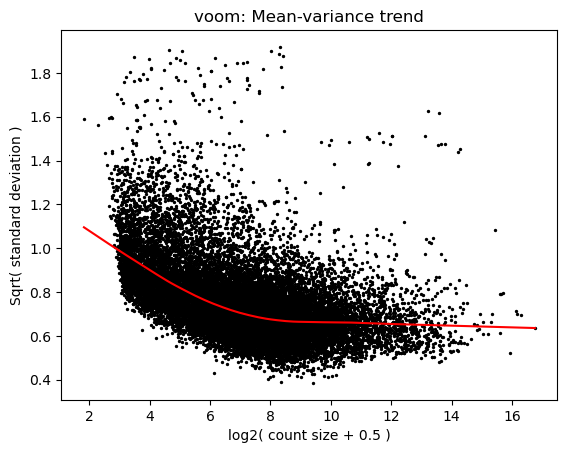

voom$E shape:       (17860, 69)
voom$weights shape: (17860, 69)


In [8]:
v = pylimma.voom(counts_f.values.astype(float), design, plot=True)
plt.show()

print(f"voom$E shape:       {v['E'].shape}")
print(f"voom$weights shape: {v['weights'].shape}")

## 8. Fit linear models and contrasts

In [9]:
fit = pylimma.lm_fit(v['E'], design, weights=v['weights'])
fit = pylimma.contrasts_fit(fit, contrasts=C)
print(f"fit$coefficients shape: {fit['coefficients'].shape}")

fit$coefficients shape: (17860, 1)


## 9. Empirical Bayes moderation

In [10]:
fit = pylimma.e_bayes(fit)
print(f"s2_prior: {fit['s2_prior']:.4f}")
print(f"df_prior: {fit['df_prior']:.2f}")

s2_prior: 0.8495
df_prior: 4.98


## 10. Top table

In [11]:
tt = pylimma.top_table(fit, coef=0, number=np.inf, sort_by='p')
tt.index = counts_f.index.astype(str)[np.argsort(np.asarray(fit['p_value']).ravel())]
print(f"DE calls at adj_p_value < 0.05: "
      f"{(tt['adj_p_value'] < 0.05).sum():,} genes")
tt.head(10)

DE calls at adj_p_value < 0.05: 52 genes


,log_fc,ave_expr,t,p_value,adj_p_value,b
ENSG00000229807,-9.754111,3.757487,-30.204314,1.273538e-42,2.274539e-38,64.596795
ENSG00000157828,3.331036,3.257210,27.465826,6.949407e-40,6.205821e-36,74.017347
ENSG00000099749,4.317234,0.263767,26.148507,1.739289e-38,1.035457e-34,62.613707
ENSG00000233864,4.953478,-0.604718,25.433224,1.056581e-37,4.717636e-34,60.339780
ENSG00000131002,5.505956,-0.221843,22.499691,2.705099e-34,9.662612e-31,56.082086
ENSG00000129824,2.828112,4.660897,19.558774,1.595046e-30,4.747922e-27,57.061885
ENSG00000213318,4.345767,2.214549,19.314856,3.413102e-30,8.708286e-27,53.976644
ENSG00000165246,5.386264,-0.542520,18.815555,1.653385e-29,3.691182e-26,48.414148
ENSG00000198692,2.476822,2.629761,18.179260,1.286432e-28,2.552852e-25,51.997921
ENSG00000243209,2.606131,-0.068742,14.467088,5.372496e-23,9.595278e-20,37.351348


## 11. MD plot

x = average log-expression, y = log fold-change
(female - male). DE calls coloured by direction.

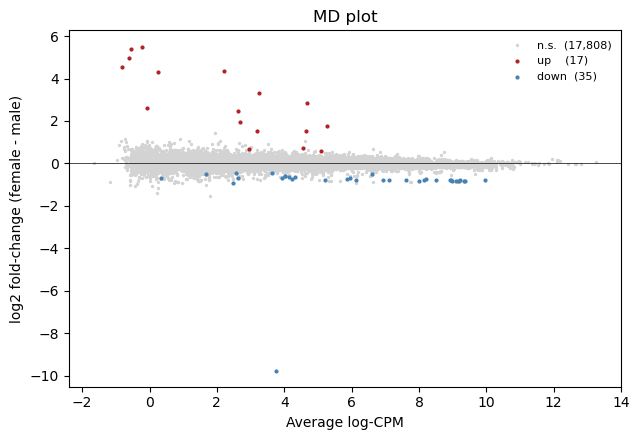

In [12]:
logFC = fit['coefficients'][:, 0]
AveExpr = fit.get('Amean') if fit.get('Amean') is not None \
          else v['E'].mean(axis=1)
adj_sig = pylimma.decide_tests(fit, p_value=0.05).ravel() != 0

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.scatter(AveExpr[~adj_sig], logFC[~adj_sig], s=2, c='lightgrey',
           label=f"n.s.  ({(~adj_sig).sum():,})")
ax.scatter(AveExpr[adj_sig & (logFC > 0)],
           logFC[adj_sig & (logFC > 0)], s=4, c='firebrick',
           label=f"up    ({(adj_sig & (logFC > 0)).sum():,})")
ax.scatter(AveExpr[adj_sig & (logFC < 0)],
           logFC[adj_sig & (logFC < 0)], s=4, c='steelblue',
           label=f"down  ({(adj_sig & (logFC < 0)).sum():,})")
ax.axhline(0, color='k', linewidth=0.5)
ax.set_xlabel('Average log-CPM')
ax.set_ylabel('log2 fold-change (female - male)')
ax.set_title('MD plot')
ax.legend(fontsize=8, frameon=False)
fig.tight_layout()
plt.show()

## 12. Volcano plot

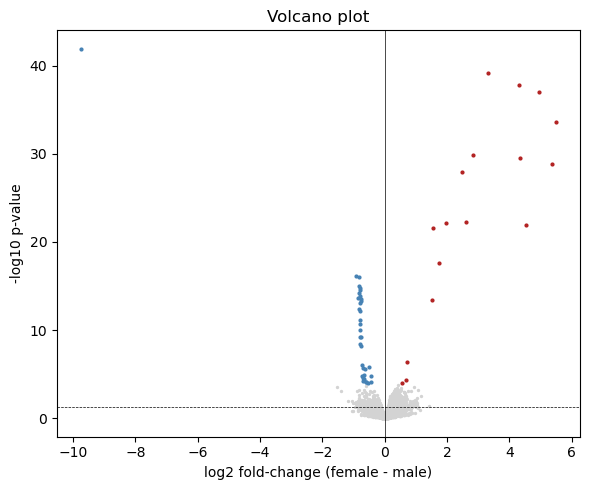

In [13]:
p = np.asarray(fit['p_value']).ravel()
neglogp = -np.log10(np.maximum(p, 1e-300))

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(logFC[~adj_sig], neglogp[~adj_sig], s=2, c='lightgrey')
ax.scatter(logFC[adj_sig & (logFC > 0)],
           neglogp[adj_sig & (logFC > 0)], s=4, c='firebrick')
ax.scatter(logFC[adj_sig & (logFC < 0)],
           neglogp[adj_sig & (logFC < 0)], s=4, c='steelblue')
ax.axhline(-np.log10(0.05), color='k', linewidth=0.5, linestyle='--')
ax.axvline(0, color='k', linewidth=0.5)
ax.set_xlabel('log2 fold-change (female - male)')
ax.set_ylabel('-log10 p-value')
ax.set_title('Volcano plot')
fig.tight_layout()
plt.show()

## 13. Heatmap of top 50 DE genes

Rows = genes ordered by **signed t-statistic** (up-regulated at
top, down-regulated at bottom). Columns grouped by cell type.
Per-gene z-scored log-CPM.

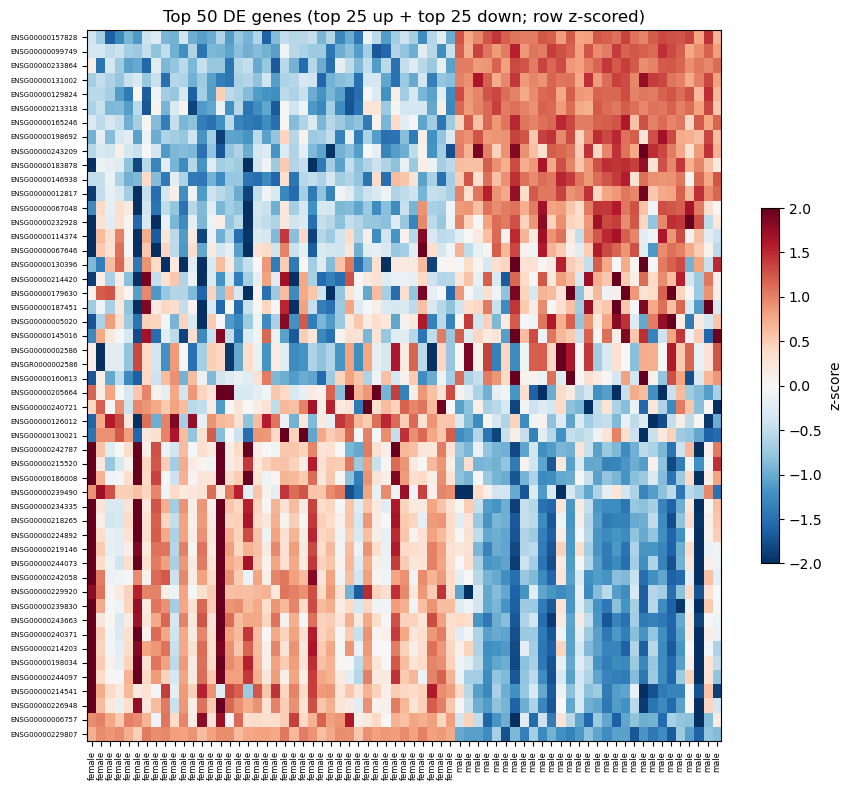

In [14]:
fig, ax = plt.subplots(figsize=(9, 8))
ax, im, ordered = plot_heatmap(v['E'], group.values, fit,
                                n_top=50, ax=ax)
gene_ids = counts_f.index.astype(str)[ordered]
ax.set_yticks(range(len(ordered)))
ax.set_yticklabels(gene_ids, fontsize=5)
fig.colorbar(im, ax=ax, shrink=0.5, label='z-score')
fig.tight_layout()
plt.show()